# E-Commerce Sales Analysis

## Project Overview

This project analyzes e-commerce sales data to identify sales trends,
top-performing product categories, order patterns, fulfilment performance,
and order cancellation trends using Python.

## Tools & Technologies

- Python
- Pandas
- Matplotlib
- Google Colab

# Import Libraries

In [1]:
import os
import pandas as pd

# Google Drive Connect

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Check Project Folder

In [3]:
project_path = "/content/drive/MyDrive/E-Commerce Project"
os.listdir(project_path)

['Expense IIGF.csv',
 'Cloud Warehouse Compersion Chart.csv',
 'Sale Report.csv',
 'International sale Report.csv',
 'May-2022.csv',
 'Amazon Sale Report.csv',
 'P  L March 2021.csv']

## Load Amazon Sales Dataset

In [4]:
file_path = os.path.join(project_path, "Amazon Sale Report.csv")
df = pd.read_csv(file_path)
df.head()

/tmp/ipykernel_1525/2550506379.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## Understand Dataset Size

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 128975
Number of columns: 24


## Dataset Information


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

## Check Missing Values

In [7]:
missing_count = df.isnull().sum()
missing_count

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


## Missing Values Percentage

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

,0
index,0.000000
Order ID,0.000000
Date,0.000000
Status,0.000000
Fulfilment,0.000000
Sales Channel,0.000000
ship-service-level,0.000000
Style,0.000000
SKU,0.000000
Category,0.000000


## Check Duplicate Records

In [9]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## Check Column Names

In [10]:
for i, column in enumerate(df.columns):
    print(i, ":", column)

0 : index
1 : Order ID
2 : Date
3 : Status
4 : Fulfilment
5 : Sales Channel 
6 : ship-service-level
7 : Style
8 : SKU
9 : Category
10 : Size
11 : ASIN
12 : Courier Status
13 : Qty
14 : currency
15 : Amount
16 : ship-city
17 : ship-state
18 : ship-postal-code
19 : ship-country
20 : promotion-ids
21 : B2B
22 : fulfilled-by
23 : Unnamed: 22


## Remove Unnecessary Columns


In [11]:
df = df.drop(columns=["index", "Unnamed: 22"])
print("Columns after cleaning:", df.shape[1])

Columns after cleaning: 22


## Explore Product Categories

In [12]:
category_counts = df["Category"].value_counts()
category_counts

,count
Category,
Set,50284
kurta,49877
Western Dress,15500
Top,10622
Ethnic Dress,1159
Blouse,926
Bottom,440
Saree,164
Dupatta,3


## Analyze Order Status

In [13]:
status_counts = df["Status"].value_counts()
status_counts

,count
Status,
Shipped,77804
Shipped - Delivered to Buyer,28769
Cancelled,18332
Shipped - Returned to Seller,1953
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


## Order Status Percentage

In [14]:
status_percentage = (df["Status"].value_counts(normalize=True) * 100).round(2)
status_percentage

,proportion
Status,
Shipped,60.32
Shipped - Delivered to Buyer,22.31
Cancelled,14.21
Shipped - Returned to Seller,1.51
Shipped - Picked Up,0.75
Pending,0.51
Pending - Waiting for Pick Up,0.22
Shipped - Returning to Seller,0.11
Shipped - Out for Delivery,0.03


## Check Order Date

In [15]:
df["Date"].head()

,Date
0,04-30-22
1,04-30-22
2,04-30-22
3,04-30-22
4,04-30-22


## Convert Date to Datetime

In [16]:
df["Date"] = pd.to_datetime(df["Date"], format="%m-%d-%y")
df["Date"].head()

,Date
0,2022-04-30
1,2022-04-30
2,2022-04-30
3,2022-04-30
4,2022-04-30


## Analyze Fulfilment Method

In [17]:
fulfilment_counts = df["Fulfilment"].value_counts()
fulfilment_counts

,count
Fulfilment,
Amazon,89698
Merchant,39277


## Fulfilment Percentage

In [18]:
fulfilment_percentage = (
    df["Fulfilment"].value_counts(normalize=True) * 100
).round(2)
fulfilment_percentage

,proportion
Fulfilment,
Amazon,69.55
Merchant,30.45


## Analyze Sales Channel

In [20]:
sales_channel_counts = df["Sales Channel "].value_counts()
sales_channel_counts

,count
Sales Channel,
Amazon.in,128851
Non-Amazon,124


## Calculate Total Quantity Sold

In [21]:
total_quantity = df["Qty"].sum()
print("Total quantity sold:", total_quantity)

Total quantity sold: 116649


## Calculate Total Sales

In [23]:
total_sales = df["Amount"].sum()
print("Total Sales Amount: ₹", round(total_sales, 2))

Total Sales Amount: ₹ 78592678.3


## Sales by Category

In [24]:
category_sales = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
category_sales

,Amount
Category,
Set,39204124.03
kurta,21299546.70
Western Dress,11216072.69
Top,5347792.30
Ethnic Dress,791217.66
Blouse,458408.18
Bottom,150667.98
Saree,123933.76
Dupatta,915.00


## Calculate Average Order Value

In [25]:
average_order_value = df["Amount"].mean()
print("Average Order Value: ₹", round(average_order_value, 2))

Average Order Value: ₹ 648.56


## Monthly Sales Analysis

In [26]:
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Amount"]
    .sum()
)
monthly_sales

,Amount
Date,
2022-03,101683.85
2022-04,28838708.32
2022-05,26226476.75
2022-06,23425809.38


## Top 5 Product Categories

In [27]:
top_categories = category_sales.head(5)
top_categories

,Amount
Category,
Set,39204124.03
kurta,21299546.70
Western Dress,11216072.69
Top,5347792.30
Ethnic Dress,791217.66


## Quantity Sold by Category

In [28]:
category_quantity = (
    df.groupby("Category")["Qty"]
    .sum()
    .sort_values(ascending=False)
)
category_quantity

,Qty
Category,
Set,45289
kurta,45045
Western Dress,13943
Top,9903
Ethnic Dress,1053
Blouse,863
Bottom,398
Saree,152
Dupatta,3


## Sales by Fulfilment Method

In [29]:
fulfilment_sales = (
    df.groupby("Fulfilment")["Amount"]
    .sum()
    .sort_values(ascending=False)
)
fulfilment_sales

,Amount
Fulfilment,
Amazon,54322151.0
Merchant,24270527.3


## Analyze Cancelled Orders

In [30]:
cancelled_orders = (df["Status"] == "Cancelled").sum()
cancelled_percentage = (cancelled_orders / len(df)) * 100

print("Cancelled Orders:", cancelled_orders)
print("Cancelled Order Percentage:", round(cancelled_percentage, 2), "%")

Cancelled Orders: 18332
Cancelled Order Percentage: 14.21 %


## Visualize Sales by Category

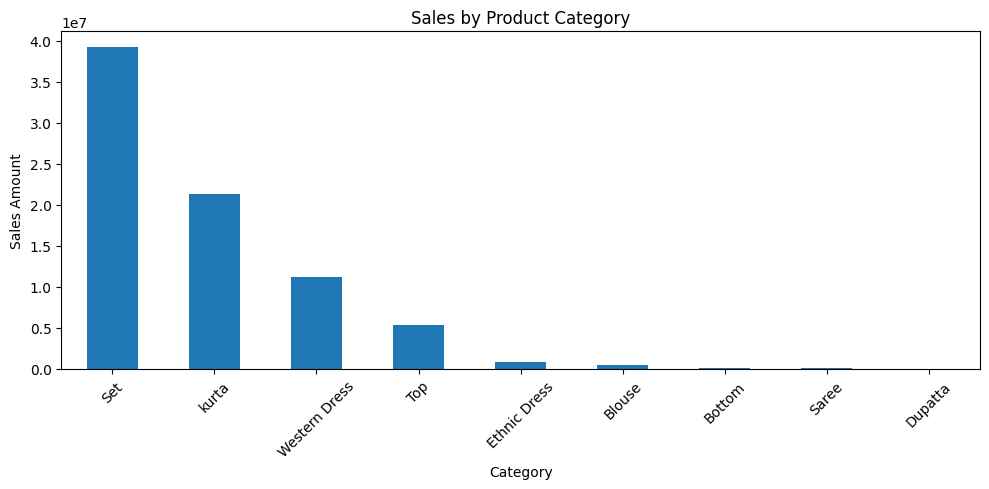

In [31]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualize Monthly Sales

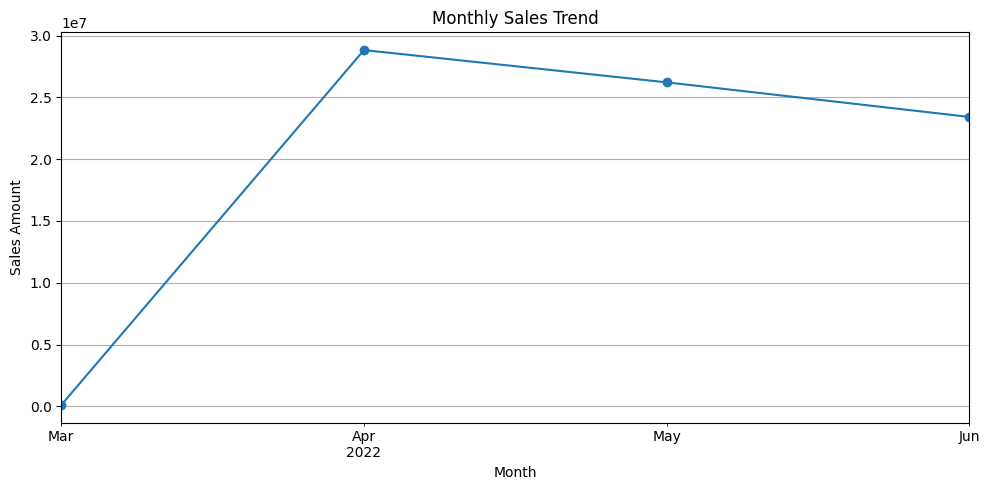

In [32]:
monthly_sales.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Visualize Sales by Fulfilment

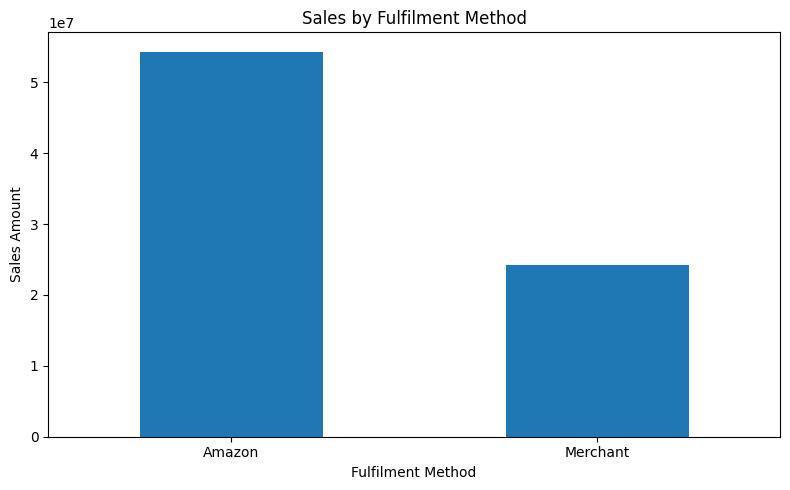

In [33]:
fulfilment_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Fulfilment Method")
plt.xlabel("Fulfilment Method")
plt.ylabel("Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualize Quantity Sold by Category

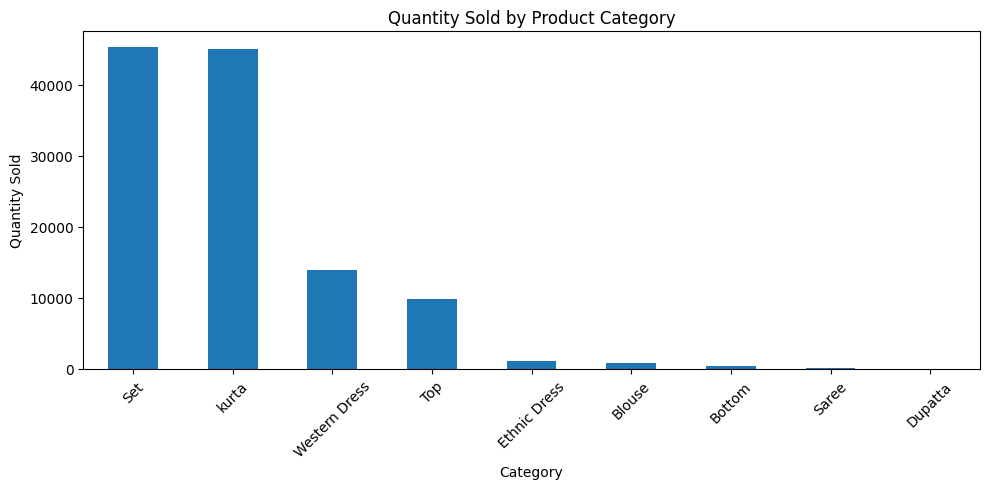

In [34]:
category_quantity.plot(kind="bar", figsize=(10, 5))

plt.title("Quantity Sold by Product Category")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualize Order Status

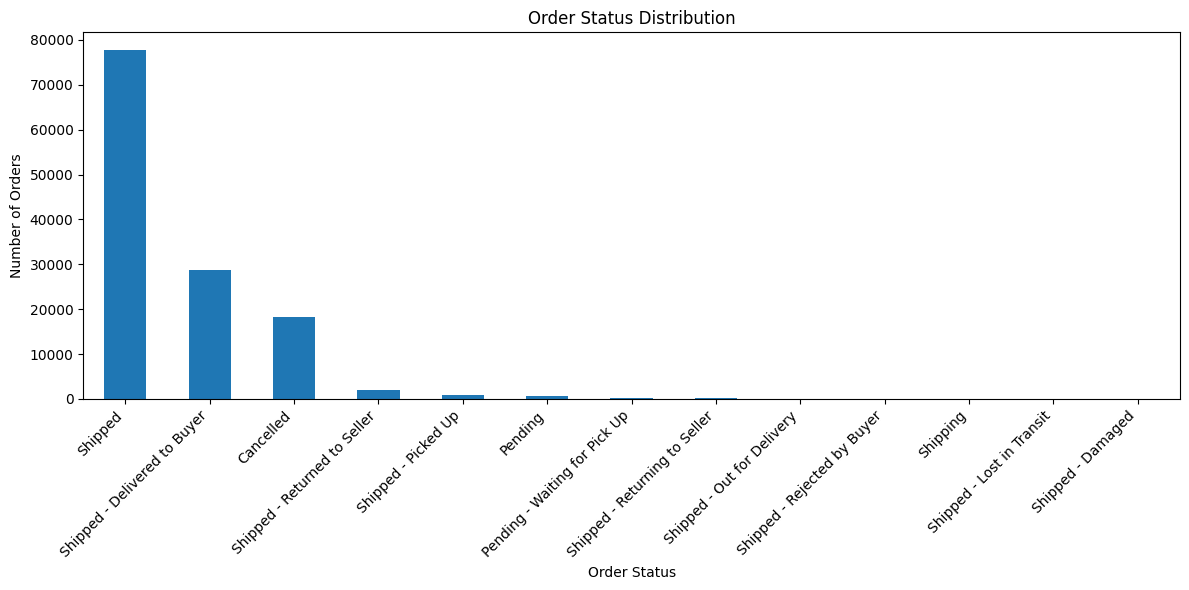

In [35]:
status_counts.plot(kind="bar", figsize=(12, 6))

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Key Business Insights
- Total quantity sold was 116,649 units.
- Total sales amount was approximately ₹7.86 crore.
- Average order value was ₹648.56.
- Set was the highest-selling category by sales amount.
- Amazon fulfilment generated higher sales than Merchant fulfilment.
- April 2022 recorded the highest monthly sales.
- 18,332 orders were cancelled, representing 14.21% of total records.
- Set and Kurta were the top categories by quantity sold.